# Diseño de realimentación de estados con LQR

*(Traducción a Python del livescript `LQR.mlx`, usando `numpy`, `scipy` y `control`)*

Vamos a ver ejemplos de ajuste de la constante $K$ empleando LQR.

Tomamos como punto de partida nuestro sistema controlable de otras veces:

$$A_c =\begin{pmatrix}1&2&0 \\ -2&3&0\\ 1&0&-2\end{pmatrix}, \quad B = \begin{pmatrix}1& 2\\ 1&0\\ 0&0\end{pmatrix}$$

In [1]:
import numpy as np
import control as ct
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

In [2]:
Ac = np.array([[1, 2, 0], [-2, 3, 0], [1, 0, -2]])
B  = np.array([[1, 2], [1, 0], [0, 0]])

## Diseño 1: acotar los estados

El ajuste de las constantes depende de qué es lo que queremos minimizar. Supongamos por ejemplo que no queremos que ninguno de los estados alcance un valor mayor que 3, y que este es nuestro único criterio.

Entonces, podemos centrar nuestro diseño en $\bar Q$: empleamos el **criterio de Bryson** y hacemos que todos los valores de la diagonal de $\bar Q$ sean de la forma $\frac{1}{3^2}$. Como no tengo criterios para $\bar R$ la tomo directamente como la matriz identidad, que deberá tener dimensión $(2\times2)$ puesto que el vector de entradas es $(2\times1)$. Además puedo tomar, por ejemplo, $\rho=0.001$; de este modo, LQR da más peso a la condición de los estados, puesto que las entradas no tienen restricción alguna.

Hay que tener en cuenta que los valores que introducimos son siempre relativos: en general, cuanto mayor el valor de $\bar Q_{ii}$, más obligamos a que la variable correspondiente sea pequeña, lo mismo para $\bar R_{ii}$.

In [3]:
Qbar = np.diag([1/3**2, 1/3**2, 1/3**2])   # criterio de Bryson
Rbar = np.eye(2)
rho = 0.001

Ahora debemos construir las matrices $Q,R,N$. Pero ¿cuál es la salida $z$ para la que quiero optimizar? En realidad son directamente los estados $z = Ix+0u$.

Luego $G=I$ y $H$ deberá ser una matriz de ceros que tenga las mismas dimensiones que $B$ (tengo que ajustar entradas con estados).

In [4]:
G = np.eye(3)
H = np.zeros((3, 2))

Ahora solo tengo que construir mis matrices para resolver la ecuación de Riccati,

$$Q = G^T\bar{Q}G, \quad R=H^T\bar{Q}H+\rho \bar{R}, \quad N = G^T\bar{Q}H$$

In [5]:
Q = G.T @ Qbar @ G
R = H.T @ Qbar @ H + rho*Rbar
N = G.T @ Qbar @ H   # aqui va a ser cero, pero hace falta pasarselo a lqr

print('Q =\n', Q)
print('R =\n', R)
print('N =\n', N)

Q =
 [[0.1111 0.     0.    ]
 [0.     0.1111 0.    ]
 [0.     0.     0.1111]]
R =
 [[0.001 0.   ]
 [0.    0.001]]
N =
 [[0. 0.]
 [0. 0.]
 [0. 0.]]


Resolvemos la ecuación de Riccati empleando `control.lqr` (equivalente a `lqr` de MATLAB, misma firma: `A, B, Q, R, N`).

In [6]:
K, P, la = ct.lqr(Ac, B, Q, R, N)
print('K =\n', K)
print('P =\n', P)
print('autovalores lazo cerrado:', la)

K =
 [[ 2.7573 12.5952  1.0762]
 [11.3338 -5.8192  1.9747]]
P =
 [[ 0.0057 -0.0029  0.001 ]
 [-0.0029  0.0155  0.0001]
 [ 0.001   0.0001  0.0265]]
autovalores lazo cerrado: [-23.8504+0.j  -9.9433+0.j  -2.2264+0.j]


$K$ es la ganancia de la realimentación, $P$ la solución de la ecuación de Riccati asociada al problema, `la` los autovalores del sistema en lazo cerrado $(A-BK)$; recordad que $(A-BK)$ debe ser una matriz de estabilidad (Hurwitz).

Si nos fijamos en los autovalores, resulta que el sistema en lazo cerrado es estable. Vamos a simularlo a ver qué salidas da (ver la función `sistema_lineal` al final del notebook).

In [7]:
def sistema_lineal(t, x, K, A, B):
    """Sistema lineal en modo realimentacion: u = -Kx."""
    u = -K @ x
    return A @ x + B @ u

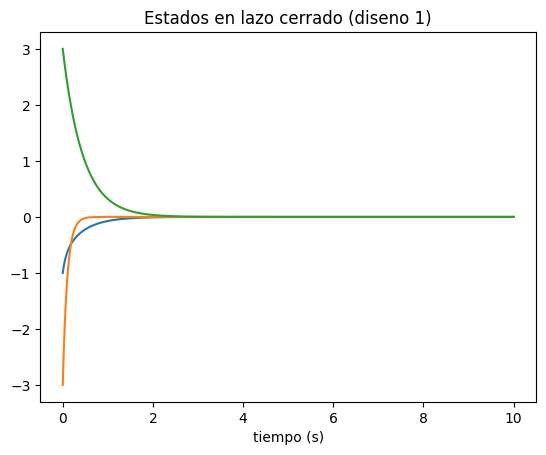

In [8]:
tf = 10
x0 = [-1, -3, 3]

sol = solve_ivp(sistema_lineal, [0, tf], x0, args=(K, Ac, B), max_step=1e-3)

plt.figure(1)
plt.plot(sol.t, sol.y.T)
plt.xlabel('tiempo (s)')
plt.title('Estados en lazo cerrado (diseno 1)')
plt.show()

Dibujamos también la señal de control,

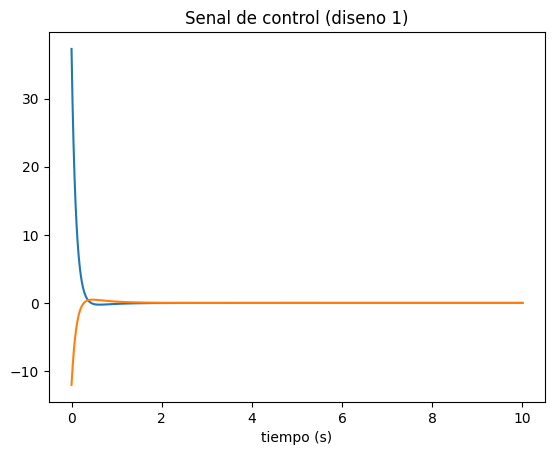

In [9]:
u = -K @ sol.y   # u(t) = -K x(t) para cada instante simulado

plt.figure(2)
plt.plot(sol.t, u.T)
plt.xlabel('tiempo (s)')
plt.title('Senal de control (diseno 1)')
plt.show()

## Diseño 2: acotar también las entradas

Podemos añadir ahora restricciones a las entradas; por ejemplo, no queremos que las entradas tomen un valor mayor de 10. Reformulamos las condiciones (mantengo el mismo $\bar Q$ del criterio de Bryson sobre los estados).

In [10]:
Qbar = np.diag([1/3**2, 1/3**2, 1/3**2])

El sistema deberá entonces intentar que las dos entradas estén por debajo de 10. Podría también darle un peso menor a una de las dos y así reforzar la condición impuesta sobre ella...

In [11]:
Rbar = np.diag([1/100, 1/100])
rho = 1   # ahora damos el mismo peso a las condiciones sobre entradas y estados

G = np.eye(3)
H = np.zeros((3, 2))

Q = G.T @ Qbar @ G
R = H.T @ Qbar @ H + rho*Rbar
N = G.T @ Qbar @ H   # aqui va a ser cero, pero hace falta pasarselo a lqr

Resolvemos de nuevo la ecuación de Riccati,

In [12]:
K, P, la = ct.lqr(Ac, B, Q, R, N)
K

array([[ 0.3921,  5.6051,  0.3979],
       [ 4.9685, -4.1844,  0.3912]])

Simulamos de nuevo para la nueva $K$,

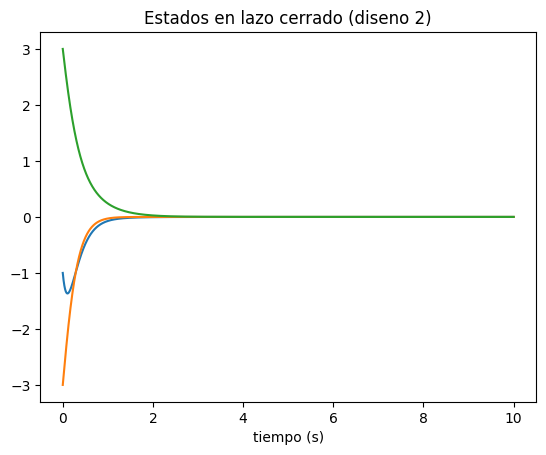

In [13]:
sol = solve_ivp(sistema_lineal, [0, tf], x0, args=(K, Ac, B), max_step=1e-3)

plt.figure(3)
plt.plot(sol.t, sol.y.T)
plt.xlabel('tiempo (s)')
plt.title('Estados en lazo cerrado (diseno 2)')
plt.show()

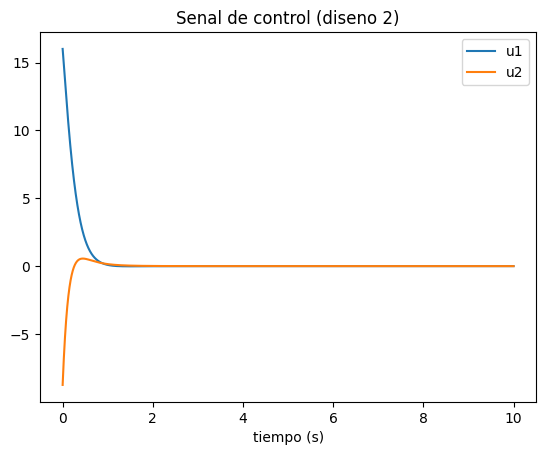

In [14]:
u = -K @ sol.y

plt.figure(4)
plt.plot(sol.t, u.T)
plt.xlabel('tiempo (s)')
plt.title('Senal de control (diseno 2)')
plt.legend(['u1', 'u2'])
plt.show()

Es interesante fijarse en que la primera entrada está fuera del límite impuesto. La razón es que el criterio de Bryson marca un límite **mínimo**. Si queremos conseguir que ambas entradas cumplan el criterio debemos forzar más la condición; una forma de hacerlo es aumentar los pesos de la matriz $\bar R$ — prueba por ejemplo con un valor $\bar r_{ii}=0.1$ (haz tú la prueba). **NOTA:** todo esto es un ejercicio de tanteo; si pruebas con otros valores puedes ver la sensibilidad de la respuesta y la entrada a los valores de $\bar Q$ y $\bar R$.

## Diseño 3: acotar solo algunos estados

Supongamos ahora que solo queremos imponer condiciones sobre los estados $x_1$ y $x_3$, pero no sobre $x_2$. Entonces podemos modificar $z$, $\bar Q$ y $H$:

$$z = \begin{pmatrix}1&0&0\\ 0&0&1\end{pmatrix}x$$

In [15]:
G = np.array([[1, 0, 0], [0, 0, 1]])       # ojo: usamos los estados x1 y x3
Qbar = np.diag([1/2**2, 1/2**2])            # criterio de Bryson: x1, x3 no superen 2
H = np.zeros((2, 2))

Q = G.T @ Qbar @ G
R = H.T @ Qbar @ H + rho*Rbar   # NOTA: no cambio Rbar, conservo el valor del ejemplo anterior
N = G.T @ Qbar @ H
rho = 0.0001   # vuelvo a relajar las condiciones sobre la entrada

**Ojo:** en el `.mlx` original, `R` se calcula con el `rho` *anterior* (`=1`) y solo *después* se redefine `rho = 0.0001` (sin volver a recalcular `R`) — es exactamente así en el original, y lo mantengo igual aquí para reproducir el mismo resultado, aunque a primera vista parezca un desliz. Resolvemos igualmente,

In [16]:
K, P, la = ct.lqr(Ac, B, Q, R, N)
K

array([[ 1.435 ,  4.5518,  0.6824],
       [ 5.9857, -3.1157,  0.6703]])

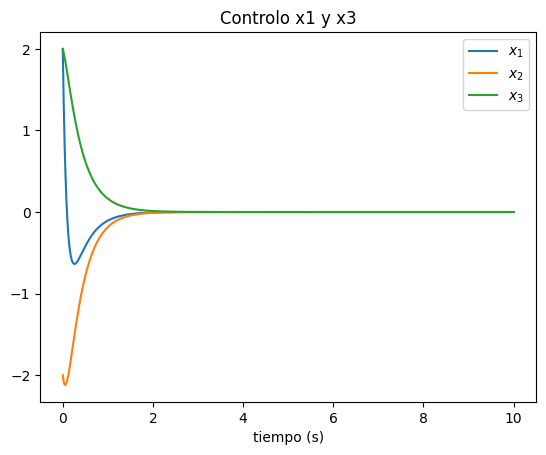

In [17]:
x0 = [2, -2, 2]

sol = solve_ivp(sistema_lineal, [0, tf], x0, args=(K, Ac, B), max_step=1e-3)

plt.figure(5)
plt.plot(sol.t, sol.y.T)
plt.xlabel('tiempo (s)')
plt.title('Controlo x1 y x3')
plt.legend([r'$x_1$', r'$x_2$', r'$x_3$'])
plt.show()

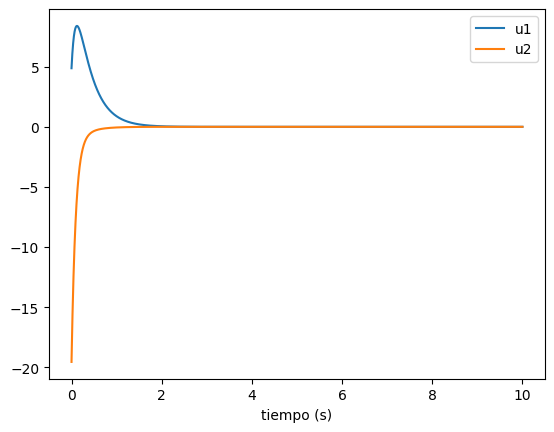

In [18]:
u = -K @ sol.y

plt.figure(6)
plt.plot(sol.t, u.T)
plt.xlabel('tiempo (s)')
plt.legend(['u1', 'u2'])
plt.show()

Si nos fijamos en los estados $x_1$ y $x_3$, cumplen la restricción impuesta. El valor de $x_2$ ahora no está sometido a restricción y toma el valor máximo que quiere. Las entradas ya no están acotadas como antes, debido al pequeño valor de $\rho$.